In [2]:
import torch
print('__CUDNN VERSION:', torch.backends.cudnn.version())
print('__Number CUDA Devices:', torch.cuda.device_count())
print('__CUDA Device Name:',torch.cuda.get_device_name(0))
print('__CUDA Device Total Memory [GB]:',torch.cuda.get_device_properties(0).total_memory/1e9)


__CUDNN VERSION: 90100
__Number CUDA Devices: 1
__CUDA Device Name: NVIDIA TITAN Xp
__CUDA Device Total Memory [GB]: 12.781879296


In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray
from dinosaur import coordinate_systems
from dinosaur import filtering
from dinosaur import primitive_equations
from dinosaur import scales
from dinosaur import sigma_coordinates
from dinosaur import spherical_harmonic
from dinosaur import time_integration
from dinosaur import vertical_interpolation

units = scales.units

# Define Utilities

In [5]:
def attach_data_array_units(array):
  attrs = dict(array.attrs)
  units = attrs.pop('units', None)
  if units in {'(0-1)', '%', '~'}:
    units = None
  if units is not None:
    data = scales.units.parse_expression(units) * array.data
  else:
    data = scales.units.dimensionless * array.data
  return xarray.DataArray(data, array.coords, array.dims, attrs=attrs)

def attach_xarray_units(ds):
  return ds.map(attach_data_array_units)

def xarray_nondimensionalize(ds):
  return xarray.apply_ufunc(scales.DEFAULT_SCALE.nondimensionalize, ds)

def xarray_to_gcm_dict(ds, var_names=None):
  if var_names is None:
    var_names = ds.keys()
  result = {}
  for var_name in var_names:
    data = ds[var_name].transpose(..., 'longitude', 'latitude').data
    if data.ndim == 2:
      data = data[np.newaxis, ...]
    result[var_name] = data
  return result

def slice_levels(output, level_indices):
  def get_horizontal(x):
    if x.shape[0] == 1:
      return x
    else:
      return x[level_indices, ...]
  return jax.tree.map(get_horizontal, output)

# Config desired outputs



In [6]:
# simulation grid
layers = 10
ref_temp_si = 250 * units.degK
model_coords = coordinate_systems.CoordinateSystem(
    spherical_harmonic.Grid.T31(),
    sigma_coordinates.SigmaCoordinates.equidistant(layers)
)

#timescales
dt_si = 5 * units.minute
save_every = 15 * units.minute
total_time = 2 * units.day + save_every
dfi_timescale = 6 * units.hour
 #which leveles to output
output_level_indices = [layers // 4, layers // 2, 3 * layers // 4, -1]

# Load source data

In [7]:
def open_Era5(path, time):
  ds = xarray.open_zarr(path, chunks = None, storage_options = dict(token='anon'))
  return ds.sel(time=time)

ds_arco_era5 = xarray.merge([
    open_Era5('gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3', time='19900501T00').drop_dims('level'),
    open_Era5('gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1', time='19900501T00'),
])

ds = ds_arco_era5[['u_component_of_wind',
                   'v_component_of_wind',
                   'temperature',
                   'specific_humidity',
                   'specific_cloud_liquid_water_content',
                   'specific_cloud_ice_water_content',
                   'surface_pressure',
                   ]]

raw_orography = ds_arco_era5.geopotential_at_surface

desired_lon = 180/np.pi * model_coords.horizontal.nodal_axes[0]
desired_lat = 180/np.pi * np.arcsin(model_coords.horizontal.nodal_axes[1])

ds_init = attach_xarray_units(ds.compute().interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] = attach_data_array_units(raw_orography.interp(latitude=desired_lat, longitude=desired_lon))
ds_init['orography'] /= scales.GRAVITY_ACCELERATION

source_vertical = vertical_interpolation.HybridCoordinates.ECMWF137()

# Build initial conditions

In [9]:
# nondimensionalize
ds_nondim_init = xarray_nondimensionalize(ds_init)
model_level_inputs = xarray_to_gcm_dict(ds_nondim_init)

sp_nodal = model_level_inputs.pop('surface_pressure')
orography_input = model_level_inputs.pop('orography')

sp_init_hpa = ds_init.surface_pressure.transpose('longitude', 'latitude').data.to('hPa').magnitude

# build inputs
physics_specs = primitive_equations.PrimitiveEquationsSpecs.from_si()

nodal_inputs = vertical_interpolation.regrid_hybrid_to_sigma(
    fields=model_level_inputs,
    hybrid_coords=source_vertical,
    sigma_coords=model_coords.vertical,
    surface_pressure=sp_init_hpa,
)
u_nodal = nodal_inputs['u_component_of_wind']
v_nodal = nodal_inputs['v_component_of_wind']
t_nodal = nodal_inputs['temperature']

# calculate vorticity & divergence
vorticity, divergence = spherical_harmonic.uv_nodal_to_vor_div_modal(
    model_coords.horizontal, u_nodal, v_nodal
)

# apply reference temperature
ref_temps = physics_specs.nondimensionalize(
    ref_temp_si * np.ones((model_coords.vertical.layers,))
)

assert ref_temps.shape == (model_coords.vertical.layers,)
temperature_variation = model_coords.horizontal.to_modal(
    t_nodal - ref_temps.reshape(-1, 1, 1)
)

log_sp = model_coords.horizontal.to_modal(np.log(sp_nodal))
tracers = model_coords.horizontal.to_modal(
    {
        'specific_humidity': nodal_inputs['specific_humidity'],
        'specific_cloud_liquid_water_content': nodal_inputs['specific_cloud_liquid_water_content'],
        'specific_cloud_ice_water_content': nodal_inputs['specific_cloud_ice_water_content'],
    }
)

# build initial state
raw_init_state = primitive_equations.State(
    vorticity=vorticity,
    divergence=divergence,
    temperature_variation=temperature_variation,
    log_surface_pressure=log_sp,
    tracers=tracers,
)

orography = model_coords.horizontal.to_modal(orography_input)
orography = filtering.exponential_filter(model_coords.horizontal, order=2)(orography)

# Setup dycore and digital filter initialization

In [10]:
# setup a simulation of the dry primitive equations
eq = primitive_equations.PrimitiveEquations(
    ref_temps, orography, model_coords, physics_specs
)

# setup hyper-spectral filter for running between dycore time-steps
res_factor = model_coords.horizontal.latitude_nodes / 128
dt = physics_specs.nondimensionalize(dt_si)
tau = physics_specs.nondimensionalize(8.6 / (2.4 ** np.log2(res_factor)) * units.hours)
hyperdiffusion_filter = time_integration.horizontal_diffusion_step_filter(
    model_coords.horizontal, dt=dt, tau=tau, order=2
)

# digital filter initialization
time_span = cutoff_period = physics_specs.nondimensionalize(dfi_timescale)
dfi = jax.jit(time_integration.digital_filter_initialization(
    equation=eq,
    ode_solver=time_integration.imex_rk_sil3,
    filters=[hyperdiffusion_filter],
    time_span=time_span,
    cutoff_period=cutoff_period,
    dt=dt,
))
%time dfi_init_state = jax.block_until_ready(dfi(raw_init_state))

CPU times: user 8.56 s, sys: 324 ms, total: 8.89 s
Wall time: 10.4 s


# Setup time integration and post processing

In [11]:
# time integration & post-processing

def nodal_prognostics_and_diagnostics(state):
  coords = model_coords.horizontal
  u_nodal, v_nodal = spherical_harmonic.vor_div_to_uv_nodal(
      coords, state.vorticity, state.divergence)
  geopotential_nodal = coords.to_nodal(
      primitive_equations.get_geopotential(
          state.temperature_variation,
          eq.reference_temperature,
          orography,
          model_coords.vertical,
          physics_specs.gravity_acceleration,
          physics_specs.ideal_gas_constant,
      )
  )
  vor_nodal = coords.to_nodal(state.vorticity)
  div_nodal = coords.to_nodal(state.divergence)
  sp_nodal = jnp.exp(coords.to_nodal(state.log_surface_pressure))
  tracers_nodal = {k: coords.to_nodal(v) for k, v in state.tracers.items()}
  t_nodal = (
      coords.to_nodal(state.temperature_variation)
      + ref_temps[:, np.newaxis, np.newaxis]
  )
  vertical_velocity_nodal = primitive_equations.compute_vertical_velocity(
      state, model_coords
  )
  state_nodal = {
      'u_component_of_wind': u_nodal,
      'v_component_of_wind': v_nodal,
      'temperature': t_nodal,
      'vorticity': vor_nodal,
      'divergence': div_nodal,
      'vertical_velocity': vertical_velocity_nodal,
      'geopotential': geopotential_nodal,
      'surface_pressure': sp_nodal,
      **tracers_nodal,
  }
  return slice_levels(state_nodal, output_level_indices)


def trajectory_to_xarray(trajectory):

  # convert units back to SI
  target_units = {k: v.data.units for k, v in ds_init.items()}
  target_units |= {
      'vorticity': units('1/s'),
      'divergence': units('1/s'),
      'geopotential': units('m^2/s^2'),
      'vertical_velocity': units('1/s'),
  }

  orography_nodal = jax.device_put(model_coords.horizontal.to_nodal(orography), device=jax.devices('cpu')[0])
  trajectory_cpu = jax.device_put(trajectory, device=jax.devices('cpu')[0])

  traj_nodal_si = {
      k: physics_specs.dimensionalize(v, target_units[k]).magnitude
      for k, v in trajectory_cpu.items()
  }

  # build xarray
  times = float(save_every / units.hour) * np.arange(outer_steps)
  lon = 180/np.pi * model_coords.horizontal.nodal_axes[0]
  lat = 180/np.pi * np.arcsin(model_coords.horizontal.nodal_axes[1])

  dims = ('time', 'sigma', 'longitude', 'latitude')
  ds_result = xarray.Dataset(
      data_vars={
          k: (dims, v) for k, v in traj_nodal_si.items() if k != 'surface_pressure'
      },
      coords={
          'longitude': lon,
          'latitude': lat,
          'sigma': model_coords.vertical.centers[output_level_indices],
          'time': times,
          'orography': (('longitude', 'latitude'), orography_nodal.squeeze()),
      },
  ).assign(
      surface_pressure=(
          ('time', 'longitude', 'latitude'),
          traj_nodal_si['surface_pressure'].squeeze(axis=-3),
      )
  )
  return ds_result

# temporal integration function
inner_steps = int(save_every / dt_si)
outer_steps = int(total_time / save_every)

step_fn = time_integration.step_with_filters(
    time_integration.imex_rk_sil3(eq, dt),
    [hyperdiffusion_filter],
)
integrate_fn = jax.jit(time_integration.trajectory_from_step(
    step_fn,
    outer_steps=outer_steps,
    inner_steps=inner_steps,
    start_with_input=True,
    post_process_fn=nodal_prognostics_and_diagnostics,
))

# Calculate outputs

In [13]:
%time out_state, trajectory = jax.block_until_ready(integrate_fn(dfi_init_state))
ds_out = trajectory_to_xarray(trajectory)

CPU times: user 389 ms, sys: 68.4 ms, total: 458 ms
Wall time: 469 ms


In [14]:
%time out_state, trajectory = jax.block_until_ready(integrate_fn(raw_init_state))
ds_out_unfiltered = trajectory_to_xarray(trajectory)

CPU times: user 381 ms, sys: 68.1 ms, total: 449 ms
Wall time: 459 ms


In [17]:
ds_out

<xarray.Dataset> Size: 146MB
Dimensions:                              (time: 193, sigma: 4, longitude: 96,
                                          latitude: 48)
Coordinates:
  * longitude                            (longitude) float64 768B 0.0 ... 356.2
  * latitude                             (latitude) float64 384B -87.16 ... 8...
  * sigma                                (sigma) float32 16B 0.25 0.55 0.75 0.95
  * time                                 (time) float64 2kB 0.0 0.25 ... 48.0
    orography                            (longitude, latitude) float32 18kB ...
Data variables:
    divergence                           (time, sigma, longitude, latitude) float32 14MB ...
    geopotential                         (time, sigma, longitude, latitude) float32 14MB ...
    specific_cloud_ice_water_content     (time, sigma, longitude, latitude) float32 14MB ...
    specific_cloud_liquid_water_content  (time, sigma, longitude, latitude) float32 14MB ...
    specific_humidity                    (time, sigma, longitude, latitude) float32 14MB ...
    temperature                          (time, sigma, longitude, latitude) float32 14MB ...
    u_component_of_wind                  (time, sigma, longitude, latitude) float32 14MB ...
    v_component_of_wind                  (time, sigma, longitude, latitude) float32 14MB ...
    vertical_velocity                    (time, sigma, longitude, latitude) float32 14MB ...
    vorticity                            (time, sigma, longitude, latitude) float32 14MB ...
    surface_pressure                     (time, longitude, latitude) float32 4MB ...

# Analyize

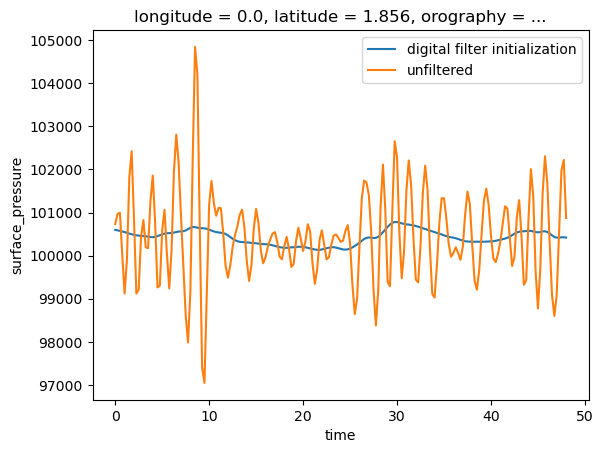

In [18]:
ds_out.surface_pressure.sel(latitude=0, longitude=0, method='nearest').plot.line(label='digital filter initialization'),
ds_out_unfiltered.surface_pressure.sel(latitude=0, longitude=0, method='nearest').plot.line(label='unfiltered'),
plt.legend()

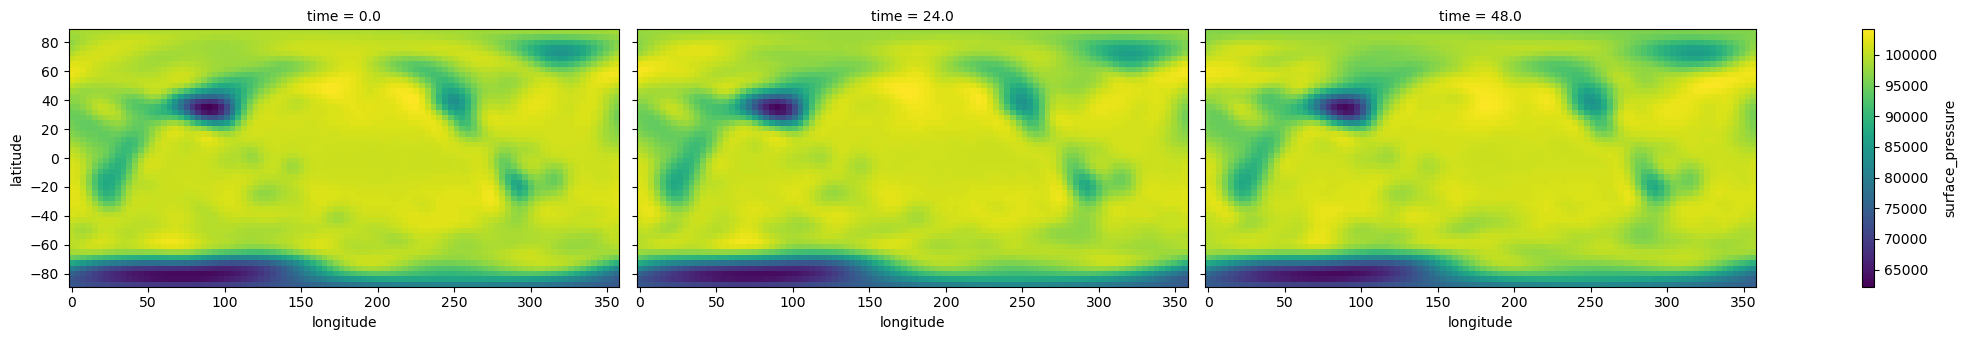

In [19]:
ds_out.surface_pressure.thin(time=4*24).plot.imshow(
    col='time', x='longitude', y='latitude',
    col_wrap=3, aspect=2, size=3.5,
    cmap='viridis',
)